In [1]:
# %% --- Cell 1: Imports ---
import os
import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import wfdb

C:\Users\91739\AppData\Roaming\Python\Python39\site-packages\pandas\core\computation\expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\91739\AppData\Roaming\Python\Python39\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.4' currently installed).
  from pandas.core import (


In [2]:
#Update this path if your data lives elsewhere
DATA_PATH = "../data/ptbxl/records/"

In [3]:
# %% [markdown]
# ## 1. Load Metadata

# %% --- Cell 2: Load database CSV ---
df = pd.read_csv(os.path.join(DATA_PATH, "ptbxl_database.csv"), index_col="ecg_id")
df["scp_codes"] = df["scp_codes"].apply(ast.literal_eval)
print(f"Total records: {len(df)}")
print(df.head(3))

Total records: 21837
        patient_id   age  sex  height  weight  nurse  site     device  \
ecg_id                                                                  
1          15709.0  56.0    1     NaN    63.0    2.0   0.0  CS-12   E   
2          13243.0  19.0    0     NaN    70.0    2.0   0.0  CS-12   E   
3          20372.0  37.0    1     NaN    69.0    2.0   0.0  CS-12   E   

             recording_date                                  report  ...  \
ecg_id                                                               ...   
1       1984-11-09 09:17:34  sinusrhythmus periphere niederspannung  ...   
2       1984-11-14 12:55:37     sinusbradykardie sonst normales ekg  ...   
3       1984-11-15 12:49:10              sinusrhythmus normales ekg  ...   

       validated_by_human baseline_drift static_noise burst_noise  \
ecg_id                                                              
1                    True            NaN    , I-V1,           NaN   
2                    True

In [4]:
 #%% [markdown]
# ## 2. Label Mapping — Risk Stratification

# %% --- Cell 3: Load SCP statements ---
scp = pd.read_csv(os.path.join(DATA_PATH, "scp_statements.csv"), index_col=0)
print(f"Total SCP codes: {len(scp)}")
print(scp.head())

Total SCP codes: 71
                          description  diagnostic  form  rhythm  \
NDT    non-diagnostic T abnormalities         1.0   1.0     NaN   
NST_          non-specific ST changes         1.0   1.0     NaN   
DIG                  digitalis-effect         1.0   1.0     NaN   
LNGQT                long QT-interval         1.0   1.0     NaN   
NORM                       normal ECG         1.0   NaN     NaN   

      diagnostic_class diagnostic_subclass  \
NDT               STTC                STTC   
NST_              STTC                NST_   
DIG               STTC                STTC   
LNGQT             STTC                STTC   
NORM              NORM                NORM   

                                      Statement Category  \
NDT                    other ST-T descriptive statements   
NST_   Basic roots for coding ST-T changes and abnorm...   
DIG                    other ST-T descriptive statements   
LNGQT                  other ST-T descriptive statements   


In [5]:
#%% --- Cell 4: Define risk buckets ---
LOW_RISK = {
    "NORM", "SR"
}

MEDIUM_RISK = {
    "IRBBB",   # Incomplete right bundle branch block
    "LAD",     # Left axis deviation
    "LAFB",    # Left anterior fascicular block
    "ISC_",    # Non-specific ischemic
    "ISCA",    # Ischemia anterior (mild)
    "IVCD",    # Intraventricular conduction delay
    "ABQRS",   # Abnormal QRS
    "PVC",     # Premature ventricular complex
    "PAC",     # Premature atrial complex
    "SVTAC",   # Supraventricular tachycardia
    "AFLT",    # Atrial flutter
    "AFIB",    # Atrial fibrillation (placed medium; will be overridden if severe)
    "SARRH",   # Sinus arrhythmia
    "SBRAD",   # Sinus bradycardia
    "STACH",   # Sinus tachycardia
}

HIGH_RISK = {
    # Myocardial Infarction variants
    "AMI", "ASMI", "ILMI", "IPLMI", "IPMI", "ISCAL",
    "ISCAN", "ISCAS", "ISCIL", "ISCIN", "ISCLA",
    "LMI", "PMI",
    # Major conduction
    "LBBB",    # Left bundle branch block
    "RBBB",    # Right bundle branch block (complete)
    "LPFB",    # Left posterior fascicular block
    # Severe rhythm
    "AVB",     # AV block
    "3AVB",    # Third degree AV block
    "2AVB",    # Second degree AV block
    "WPW",     # Wolff-Parkinson-White
    "VTACH",   # Ventricular tachycardia
    "VFIB",    # Ventricular fibrillation
    # ST / ischemia
    "STD_",    # ST depression
    "STE_",    # ST elevation
    "NST_",    # Non-specific ST changes (severe)
}

def assign_risk(scp_codes: dict) -> str:
    """
    Worst-case-wins policy:
    If any code maps to High → High
    Elif any code maps to Medium → Medium
    Else → Low
    """
    codes = set(scp_codes.keys())
    if codes & HIGH_RISK:
        return "High"
    elif codes & MEDIUM_RISK:
        return "Medium"
    else:
        return "Low"

df["risk_label"] = df["scp_codes"].apply(assign_risk)
print(df["risk_label"].value_counts())


risk_label
Low       10399
Medium     5821
High       5617
Name: count, dtype: int64


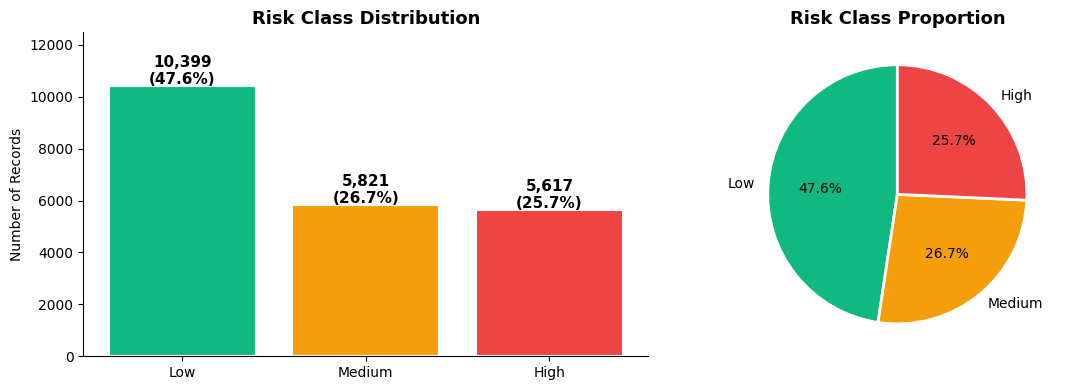

Saved → results/figures/class_distribution.png


In [6]:
#%% [markdown]
# ## 3. Class Distribution

# %% --- Cell 5: Plot class distribution ---
counts = df["risk_label"].value_counts().reindex(["Low", "Medium", "High"])
colors = ["#10b981", "#f59e0b", "#ef4444"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
axes[0].bar(counts.index, counts.values, color=colors, edgecolor="white", linewidth=1.5)
for i, (idx, val) in enumerate(counts.items()):
    axes[0].text(i, val + 80, f"{val:,}\n({val/len(df)*100:.1f}%)",
                 ha="center", fontsize=11, fontweight="bold")
axes[0].set_title("Risk Class Distribution", fontsize=13, fontweight="bold")
axes[0].set_ylabel("Number of Records")
axes[0].set_ylim(0, counts.max() * 1.2)
axes[0].spines[["top","right"]].set_visible(False)

# Pie chart
axes[1].pie(counts.values, labels=counts.index, colors=colors,
            autopct="%1.1f%%", startangle=90,
            wedgeprops={"edgecolor": "white", "linewidth": 2})
axes[1].set_title("Risk Class Proportion", fontsize=13, fontweight="bold")

plt.tight_layout()
plt.savefig("../results/figures/class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → results/figures/class_distribution.png")




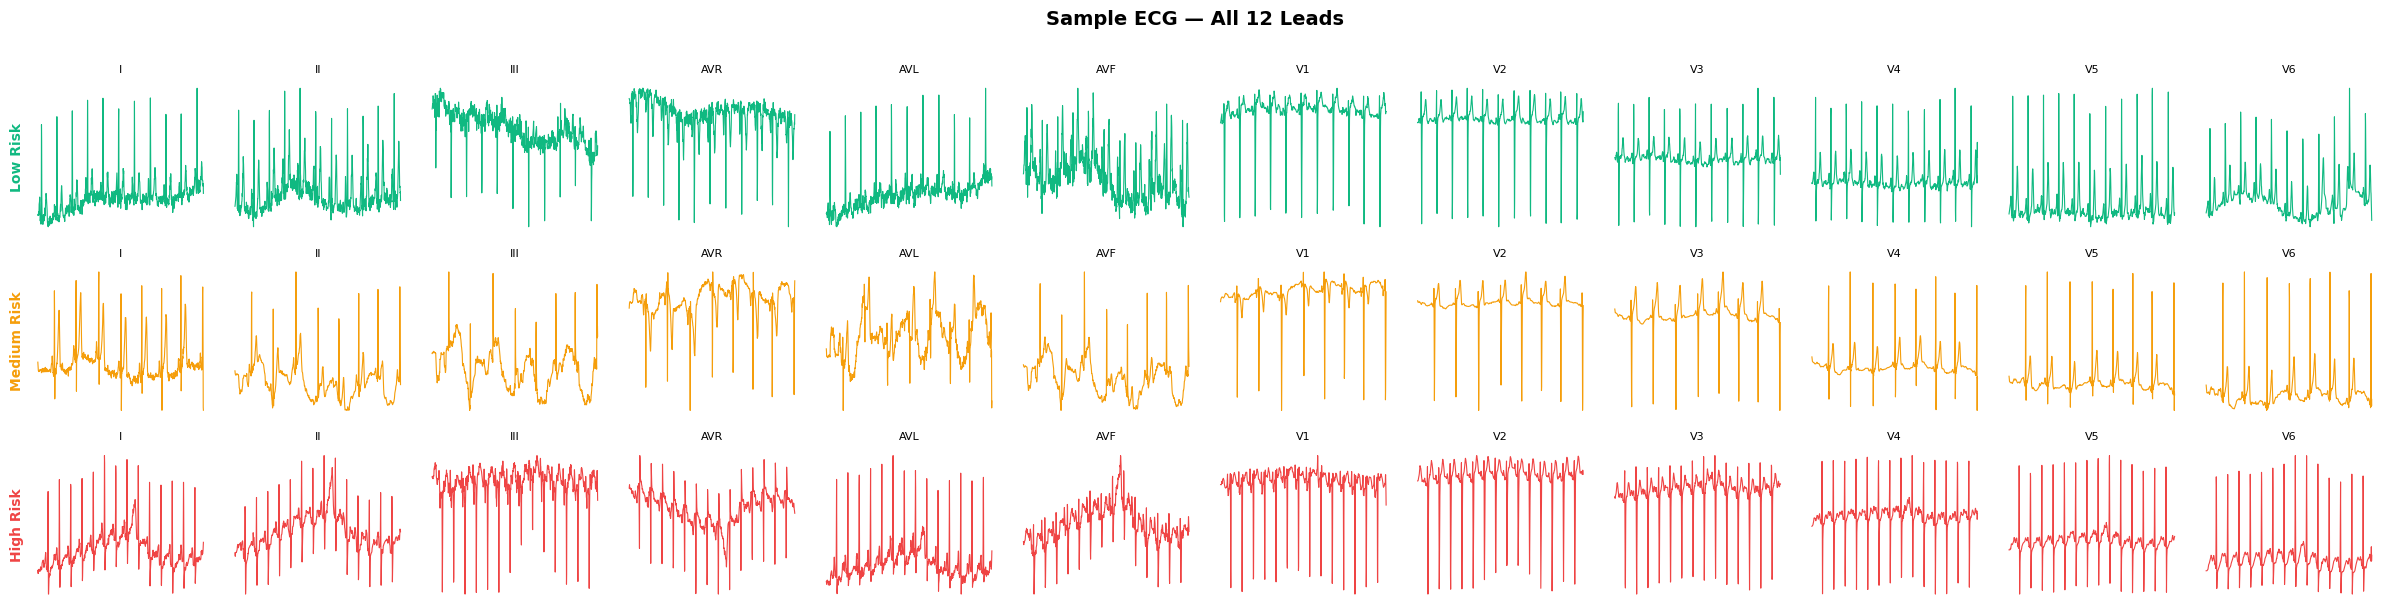

Saved → results/figures/ecg_samples.png


In [7]:
#%% [markdown]
# ## 4. Visualize Raw ECG Signals per Risk Class

# %% --- Cell 6: Plot sample ECGs ---
def plot_ecg_sample(record_path, title, color, ax_row, axes):
    record = wfdb.rdrecord(record_path)
    signal = record.p_signal  # shape: (1000, 12)
    lead_names = record.sig_name
    for j, ax in enumerate(ax_row):
        ax.plot(signal[:, j], color=color, linewidth=0.8)
        ax.set_title(lead_names[j], fontsize=8)
        ax.set_xticks([]); ax.set_yticks([])
        ax.spines[["top","right","left","bottom"]].set_visible(False)

risk_colors = {"Low": "#10b981", "Medium": "#f59e0b", "High": "#ef4444"}
fig, axes = plt.subplots(3, 12, figsize=(24, 6))
fig.suptitle("Sample ECG — All 12 Leads", fontsize=14, fontweight="bold", y=1.01)

for i, risk in enumerate(["Low", "Medium", "High"]):
    sample = df[df["risk_label"] == risk].iloc[0]
    # PTB-XL uses records100 at 100 Hz
    rec_path = os.path.join(DATA_PATH, sample["filename_lr"].replace(".hea", ""))
    axes[i][0].set_ylabel(f"{risk} Risk", fontsize=10,
                          color=risk_colors[risk], fontweight="bold", rotation=90)
    try:
        plot_ecg_sample(rec_path, risk, risk_colors[risk], axes[i], axes[i])
    except Exception as e:
        print(f"Could not load {risk} sample: {e}")

plt.tight_layout()
plt.savefig("../results/figures/ecg_samples.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → results/figures/ecg_samples.png")


In [8]:
## 5. Summary Stats

# %% --- Cell 7: Dataset summary ---
print("=" * 45)
print("PTB-XL Dataset Summary")
print("=" * 45)
print(f"Total records     : {len(df):,}")
print(f"Unique patients   : {df['patient_id'].nunique():,}")
print(f"Sampling rate     : 100 Hz (filename_lr)")
print(f"Signal length     : 10 seconds → 1000 timesteps")
print(f"Leads             : 12")
print()
print("Risk Label Distribution:")
for label in ["Low", "Medium", "High"]:
    n = (df["risk_label"] == label).sum()
    print(f"  {label:8s}: {n:5,}  ({n/len(df)*100:.1f}%)")
print()
print("Class imbalance ratio (High:Low):",
      round((df["risk_label"]=="Low").sum() / (df["risk_label"]=="High").sum(), 2))

PTB-XL Dataset Summary
Total records     : 21,837
Unique patients   : 18,885
Sampling rate     : 100 Hz (filename_lr)
Signal length     : 10 seconds → 1000 timesteps
Leads             : 12

Risk Label Distribution:
  Low     : 10,399  (47.6%)
  Medium  : 5,821  (26.7%)
  High    : 5,617  (25.7%)

Class imbalance ratio (High:Low): 1.85
